# 01 · Conjunto de latidos MIT-BIH (versión `mitdb_binario_v1`)

Este notebook **no procesa datos**: solo carga el conjunto que construye
`uv run python -m qcnn_ecg.preparar_datos` y lo describe. Así la CNN, la QCNN y el
prototipo usan exactamente los mismos latidos y la misma partición.

**Resumen del pipeline** (ver `src/qcnn_ecg/`):

| Paso | Decisión |
| :--- | :--- |
| Derivación | MLII, buscada por nombre (en el registro 114 está en el canal 1) |
| Filtrado | Butterworth orden 4, pasa-banda 0.5–40 Hz, `filtfilt` |
| Normalización | z-score por registro |
| Segmentación | ventana de 288 muestras (±0.4 s) centrada en el pico R anotado |
| Etiquetas | 0 = `N`; 1 = `L R A a J S V E F j e`; se descartan `Q` y latidos de marcapasos |
| Partición | DS1/DS2 (de Chazal, 2004), sin registros con marcapasos (102, 104, 107, 217). Validación por paciente dentro de DS1 (semilla 42). El 202 (misma persona que el 201) se excluye de la prueba y se reporta aparte |

In [1]:
import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from qcnn_ecg import config
from qcnn_ecg.conjunto import cargar_conjunto

conjunto = cargar_conjunto()  # verifica los SHA-256 del manifiesto
manifiesto = json.loads((config.DIR_MANIFIESTOS / f"{config.NOMBRE_CONJUNTO}.json").read_text(encoding="utf-8"))
print("Forma de X:", conjunto.X.shape, "| tipo:", conjunto.X.dtype)
print("Forma de y:", conjunto.y.shape)

Forma de X: (100673, 288) | tipo: float32
Forma de y: (100673,)


## Tamaño de cada partición

In [2]:
filas = []
for p in config.PARTICIONES:
    c = manifiesto["conteos"][p]
    filas.append({
        "partición": p,
        "registros": ", ".join(manifiesto["registros_por_particion"][p]),
        "latidos": c["latidos"],
        "normal": c["normal"],
        "anormal": c["anormal"],
        "% anormal": round(100 * c["anormal"] / c["latidos"], 1),
    })
pd.DataFrame(filas).set_index("partición")

,registros,latidos,normal,anormal,% anormal
partición,,,,,
entrenamiento,"101, 109, 112, 114, 115, 118, 119, 122, 124, 2...",40276,29969,10307,25.6
validacion,"106, 108, 116, 205, 207",10714,8116,2598,24.2
prueba,"100, 103, 105, 111, 113, 117, 121, 123, 200, 2...",47548,34366,13182,27.7
prueba_excluida,202,2135,2060,75,3.5


## Tipos de latido por partición

Cada símbolo es la anotación original del cardiólogo. Todos los tipos anormales relevantes (L, R, V, A, F) aparecen en entrenamiento y en prueba.

In [3]:
tabla = pd.DataFrame({p: manifiesto["conteos"][p]["simbolos"] for p in config.PARTICIONES}).fillna(0).astype(int)
tabla.loc[tabla.sum(axis=1).sort_values(ascending=False).index]

,entrenamiento,validacion,prueba,prueba_excluida
N,29969,8116,34366,2060
L,2490,1457,4124,0
R,3695,85,3475,0
V,2861,822,3200,19
A,695,115,1700,36
F,401,13,387,1
j,15,1,213,0
a,100,0,31,19
E,0,105,1,0
J,32,0,51,0


## Latido promedio por clase y ejemplos por tipo

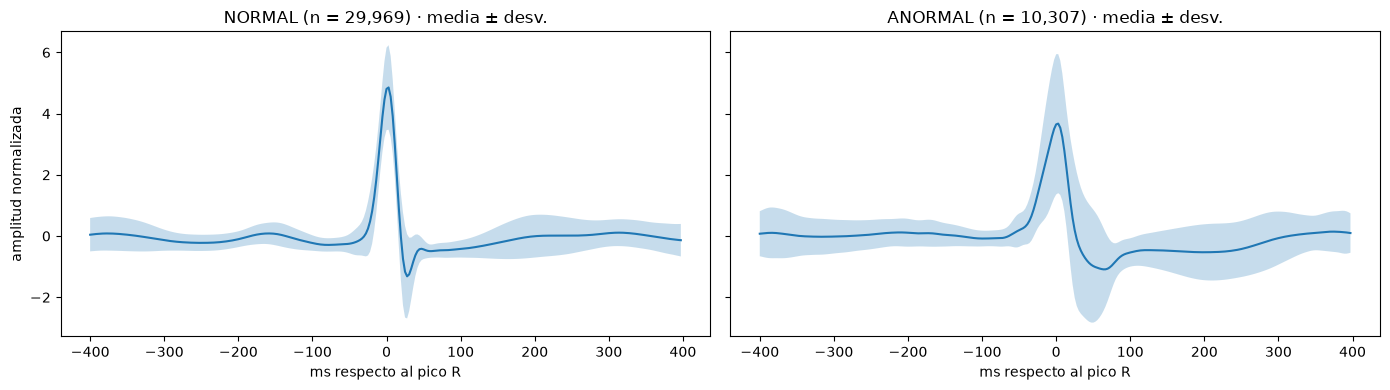

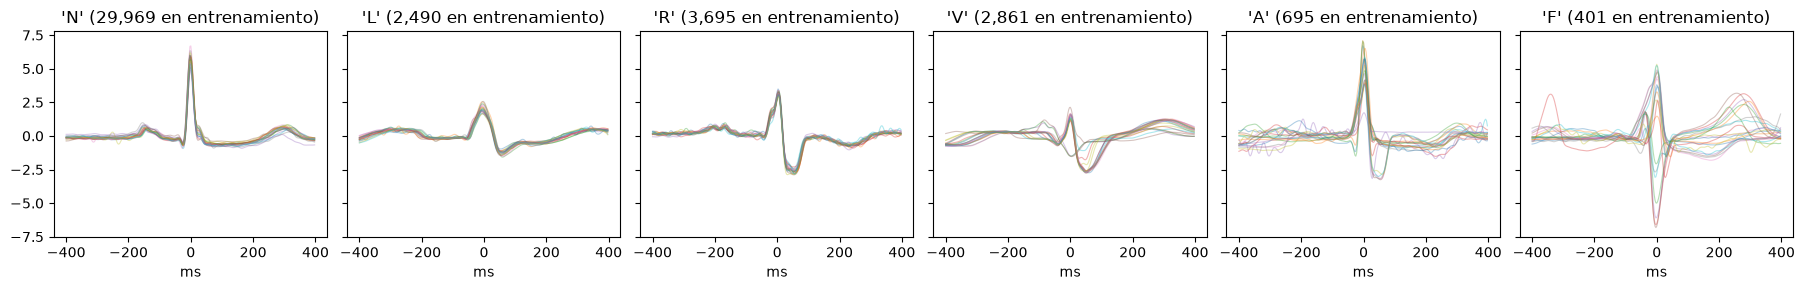

In [4]:
t = (np.arange(config.LONGITUD_VENTANA) - config.MEDIA_VENTANA) / config.FS * 1000
entrenamiento = conjunto.mascara("entrenamiento")
fig, ejes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for clase, nombre in enumerate(config.NOMBRES_CLASES):
    X = conjunto.X[entrenamiento & (conjunto.y == clase)]
    media, desv = X.mean(0), X.std(0)
    ejes[clase].plot(t, media)
    ejes[clase].fill_between(t, media - desv, media + desv, alpha=0.25)
    ejes[clase].set_title(f"{nombre} (n = {len(X):,}) · media ± desv.")
    ejes[clase].set_xlabel("ms respecto al pico R")
ejes[0].set_ylabel("amplitud normalizada")
plt.tight_layout(); plt.show()

simbolos = ["N", "L", "R", "V", "A", "F"]
fig, ejes = plt.subplots(1, len(simbolos), figsize=(18, 3), sharey=True)
for eje, s in zip(ejes, simbolos):
    idx = np.flatnonzero(entrenamiento & (conjunto.simbolo == s))[:20]
    eje.plot(t, conjunto.X[idx].T, alpha=0.35, lw=0.8)
    eje.set_title(f"'{s}' ({(entrenamiento & (conjunto.simbolo == s)).sum():,} en entrenamiento)")
    eje.set_xlabel("ms")
plt.tight_layout(); plt.show()

## Reproducibilidad

SHA-256 de los archivos procesados. Al regenerar el conjunto deben coincidir exactamente.

In [5]:
pd.Series(manifiesto["sha256"], name="sha256").to_frame()

,sha256
X,a899373cd5c7bc8c7a4c43b36ea5042ff3e96cefcd049e...
y,942b5b7025bc9b82914330ac864ba49e5911f1fafe9790...
registro,ac1ee2e2a85a3ed1a495ea67d401fb7e14b3c3c4ca6b34...
simbolo,9321349264799017d981b2980289386c7a52ccde068004...
muestra_r,39e10fd6690b008bf1c1ac3c866c5e12ca9b52cbef85f5...
particion,18572131ac5dd5c691308168793f976556205e8d5ff426...
